# Lab 04: The Scaling Relation That Depends on How You Fit It

**ASTR 457, Fall 2026, posted Thu Sep 24, due Wed Sep 30 by Noon (fork → PR, as always)**

**Extra credit, +5 points on this lab:** if you attended Charlotte Ward's Sep 22 Astronomy Colloquium, turn in at least a page of notes including two questions you had, as a text file in your `submissions/<netid>/` folder, by Noon Tue Sep 29.

*Why this lab: every scaling relation you will ever use ($M_{\rm BH}$–$\sigma$, Tully–Fisher, the mass–metallicity relation, the SN Ia standardization) was fit by someone who chose a regression method, and the choice changes the published slope. Knowing when ordinary least squares lies, by how much, and what to do instead is how you read those papers, and how you referee them.*

Every one of you has your own dataset: `data/<your netid>.csv`, a sample of dwarf
galaxies hosting active galactic nuclei, selected by their optical variability in the
style of Ward et al. (2022, arXiv:2110.13098). Dwarf-galaxy AGN are one of the few
windows we have on black holes in the $10^5$–$10^7\,M_\odot$ range, where the seeds of
supermassive black holes hide. Columns:

- `logMstar`, `err_logMstar`: $x = \log_{10}(M_*/M_\odot)$, the host stellar mass from
  SED fitting, and its $1\sigma$ uncertainty (0.2–0.4 dex; dwarf-galaxy photometry is hard),
- `logMBH`, `err_logMBH`: $y = \log_{10}(M_{\rm BH}/M_\odot)$, the virial black-hole
  mass from broad-line spectroscopy, and its $1\sigma$ uncertainty.

The relation you are after is

$$y = \alpha\,(x - 9.5) + \beta + \text{intrinsic scatter } \sigma_{\rm int},$$

pivoted at $M_* = 10^{9.5} M_\odot$ so $\alpha$ and $\beta$ don't fight each other. **Both
variables have measurement error, and the relation has real astrophysical scatter on top.**
I know your true $\alpha$, $\beta$, and $\sigma_{\rm int}$. You don't, your classmates'
values are different from yours, and so are your sample sizes.

**How this is graded.** Not on whether your code runs, but on whether your answers are
*right* and your uncertainties are *honest*. Part of your grade comes from how close your
reported $\alpha$ and $\beta$ are to your truth **in units of your own reported
uncertainty**. Tiny error bars you can't back up lose points; padded ones lose points too.
Calibration is the skill. The floor under "padded": your reported $\sigma_\alpha$ may not
exceed **3× the curvature uncertainty of your own generative fit** from Part 2 (if your
Hessian turns out singular, quote a profile-likelihood width instead and say so). Bigger
than that is not caution, since it's an estimator you should have discarded.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and document
it in Part 4. You may be selected to defend this lab in person. Welcome to doing research.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = np.genfromtxt('../../labs/04/data/claym2.csv', delimiter=',', names=True)
df = pd.DataFrame(data)
df.head(10)

,logMstar,err_logMstar,logMBH,err_logMBH
0,7.984159,0.277929,5.117924,0.390867
1,8.154205,0.292511,4.781752,0.379672
2,8.308223,0.318851,6.740068,0.306365
3,8.448144,0.205869,4.702383,0.337801
4,8.597814,0.326491,6.754409,0.332058
5,8.611335,0.319485,6.706270,0.350470
6,8.614700,0.249753,5.496639,0.382180
7,8.741448,0.212257,5.447603,0.378960
8,8.758882,0.363179,5.056748,0.251293
9,8.786474,0.232597,5.632354,0.252115


## Part 1: The fit everyone does first (15%)

Load your sample and plot it with error bars **on both axes**. Then fit the relation the
way most papers still do: **ordinary least squares** on $y$ vs $(x - 9.5)$, every point
weighted equally, errors ignored. Build the design matrix and solve the normal equations
yourself (lecture machinery, or `np.polyfit` if you must, but know what it's doing). Report
$\hat\alpha \pm \sigma$ using the standard OLS variance estimate, $s^2 (A^{\mathsf T}A)^{-1}$
with $s^2 = \mathrm{RSS}/(N-2)$ (residual-scaled; the errors play no role yet, on purpose).

Then answer, in a few sentences: which of OLS's assumptions does *your* dataset violate?
For the slope specifically, which way does the bias from the $x$-errors pull, and what
controls its size? (We named it in lecture on Sep 24. The effect is *supposed*
to be there; understanding exactly why, on your own data, is the point of this lab.)

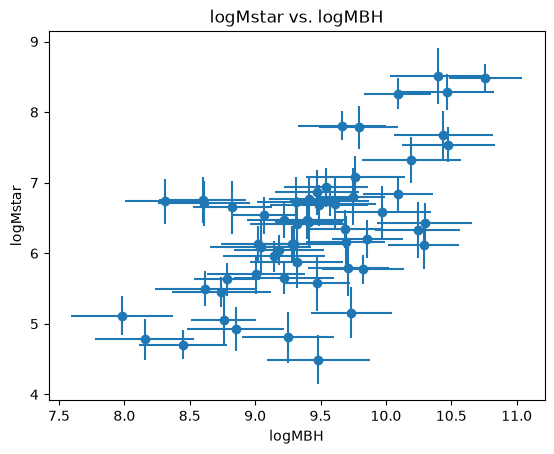

In [2]:
plt.errorbar(df["logMstar"],df["logMBH"],yerr=df["err_logMstar"],xerr=df["err_logMBH"],fmt="o")

plt.title("logMstar vs. logMBH")
plt.ylabel("logMstar")
plt.xlabel("logMBH")
plt.show()

slope (alpha) = 0.956 +/- 0.158
intercept (beta) = 6.432 +/- 0.097


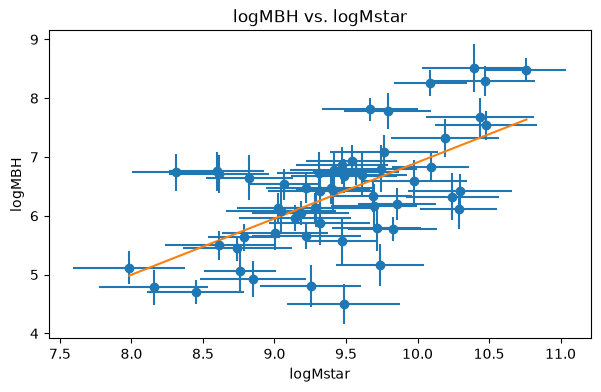

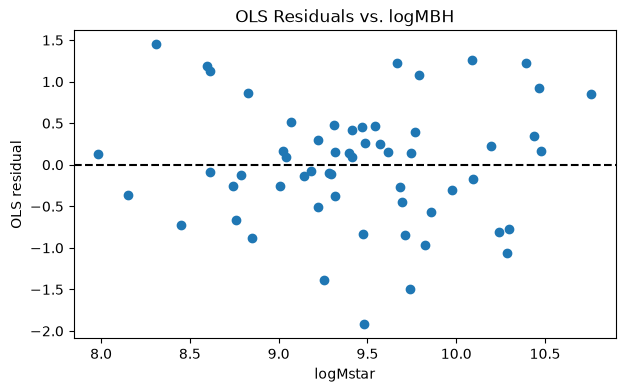

In [3]:
def ols(A, y):
    """theta_hat, its covariance (residual-scaled) and the residuals, for design matrix A and data y."""
    AtA_inv = np.linalg.inv(A.T @ A)
    theta = AtA_inv @ A.T @ y
    resid = y - A @ theta
    s2 = resid @ resid / (len(y) - A.shape[1])
    return theta, s2 * AtA_inv, resid


x = df["logMstar"].values
x_c = x - 9.5
y = df["logMBH"].values

A = np.vstack([np.ones_like(x_c), x_c]).T
theta, cov, resid = ols(A, y)
beta_hat, alpha_hat = theta
sig_beta, sig_alpha = np.sqrt(np.diag(cov))

print(f"slope (alpha) = {alpha_hat:.3f} +/- {sig_alpha:.3f}")
print(f"intercept (beta) = {beta_hat:.3f} +/- {sig_beta:.3f}")

plt.figure(figsize=(7,4))
plt.errorbar(x, y, xerr=df["err_logMBH"], yerr=df["err_logMstar"], fmt="o")

xx = np.linspace(x.min(), x.max(), 100)
yy = alpha_hat * (xx - 9.5) + beta_hat

plt.plot(xx, yy)
plt.ylabel("logMBH")
plt.xlabel("logMstar")
plt.title("logMBH vs. logMstar")
plt.show()


plt.figure(figsize=(7,4))
plt.scatter(x, resid)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("logMstar")
plt.ylabel("OLS residual")
plt.title("OLS Residuals vs. logMBH")
plt.show()

**ANSWER (a few sentences):**

In the plot above, we have error at each point along the x and y axis, meaning that the slope is going to have a shallow bias. OLS is not accounting for the error in the logMBH category, meaning that the model will not accurately predict the real values that contain measurement error. With this method alone, we will under predict the slope.

## Part 2: Estimators you can defend (40%)

Now fit the relation **three more ways** and compare:

1. **Weighted least squares** using the $y$-errors only:
   $\hat{\theta} = (A^{\mathsf T}\Sigma^{-1}A)^{-1}A^{\mathsf T}\Sigma^{-1}y$ with
   $\Sigma = \mathrm{diag}(\sigma_{y,i}^2)$, parameter covariance
   $(A^{\mathsf T}\Sigma^{-1}A)^{-1}$. Does weighting fix the Part 1 bias? Why or why not?

2. **Orthogonal distance regression** (`scipy.odr`, which warns that it is deprecated on
   import; that is fine in the course environment), which knows about the $x$-errors.
   Read what it minimizes before you run it. What does ODR assume about scatter
   *perpendicular to the relation*, and is that assumption true here?

3. **The generative model, honestly.** Write down where each data point comes from:
   the true stellar masses are drawn from the population,
   $x_i^{\rm true} \sim \mathcal{N}(\mu, \sigma_{\rm pop}^2)$; the relation plus intrinsic scatter
   makes the true BH mass; and your measurement errors corrupt both. Marginalizing over
   the (unobservable) true masses makes each observed pair $(x_i, y_i)$ a **bivariate
   Gaussian**:

   $$\begin{pmatrix} x_i \\ y_i \end{pmatrix} \sim \mathcal{N}\!\left[
   \begin{pmatrix} \mu \\ \alpha(\mu - 9.5) + \beta \end{pmatrix},\;
   \begin{pmatrix} \sigma_{\rm pop}^2 + \sigma_{x,i}^2 & \alpha\,\sigma_{\rm pop}^2 \\
   \alpha\,\sigma_{\rm pop}^2 & \alpha^2\sigma_{\rm pop}^2 + \sigma_{\rm int}^2 + \sigma_{y,i}^2 \end{pmatrix}
   \right]$$

   (Convince yourself of the three variance entries before you code; the off-diagonal
   covariance is what removes the attenuation bias. This is the Gaussian core of Kelly 2007, the paper behind
   every modern `linmix`-style fit.) Maximize the summed log-likelihood over all five
   parameters $(\alpha, \beta, \sigma_{\rm int}, \mu, \sigma_{\rm pop})$, and get uncertainties from
   the curvature of the log-likelihood at its peak (the observed information), and say so.

Make **one plot with all four fitted lines overplotted** on your data. They will not agree.
Explain, estimator by estimator, *why* each lands where it does, and which ingredient of the
data each one ignores.

Commit to a **final answer**: one $\alpha \pm \sigma$, $\beta \pm \sigma$, and
$\sigma_{\rm int} \pm \sigma$ you'd put in a paper, and justify the choice. Remember the
3× rule from the header.

chi2 = 299.07
degrees of freedom = 56
reduced chi2 = 5.34
alpha_WLS = 0.932 +/- 0.070
beta_WLS  = 6.443 +/- 0.042


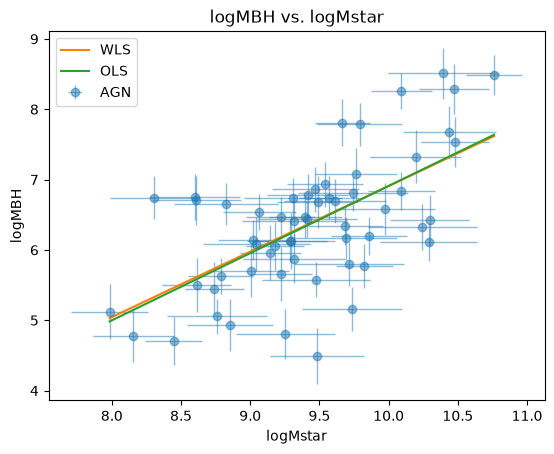

In [4]:
def wls(A, y, sigma):
    """theta_hat and its covariance from the error bars, for diagonal Sigma."""
    W = 1.0 / sigma**2
    AtWA_inv = np.linalg.inv(A.T @ (A * W[:, None]))
    theta = AtWA_inv @ A.T @ (W * y)
    return theta, AtWA_inv

x = df["logMstar"].values
y = df["logMBH"].values
sigma_y = df["err_logMBH"].values
A = np.vstack([np.ones_like(x), x - 9.5]).T

theta_w, cov_w = wls(A, y, sigma_y)
beta_w, alpha_w = theta_w
sig_beta_w, sig_alpha_w = np.sqrt(np.diag(cov_w))

chi2_w = np.sum(((y - A @ theta_w) / sigma_y)**2)
nu_w = len(y) - 2

z = (y - A @ theta_w) / sigma_y

print(f"chi2 = {chi2_w:.2f}")
print(f"degrees of freedom = {nu_w}")
print(f"reduced chi2 = {chi2_w / nu_w:.2f}")
print(f"alpha_WLS = {alpha_w:.3f} +/- {sig_alpha_w:.3f}")
print(f"beta_WLS  = {beta_w:.3f} +/- {sig_beta_w:.3f}")


xx = np.linspace(x.min(), x.max(), 100)
yy = alpha_hat * (xx - 9.5) + beta_hat
yy_wls = beta_w + alpha_w * (xx - 9.5)

plt.errorbar(x,y, xerr=df["err_logMstar"], yerr=df["err_logMBH"], fmt="o",alpha=0.5,linewidth=1,label="AGN")
plt.plot(xx, yy_wls, label="WLS")
plt.plot(xx, yy, label="OLS")

plt.ylabel("logMBH")
plt.xlabel("logMstar")
plt.legend()
plt.title("logMBH vs. logMstar")
plt.show()

alpha_ODR = 1.782 +/- 0.210
beta_ODR  = 6.521 +/- 0.112


/var/folders/1_/x9v87_qs7_nb9mx28cmcd1c80000gn/T/ipykernel_1686/3060953358.py:1: DeprecationWarning: `scipy.odr` is deprecated as of version 1.17.0 and will be removed in SciPy 1.19.0. Please use `https://pypi.org/project/odrpack/` instead.
  from scipy import odr


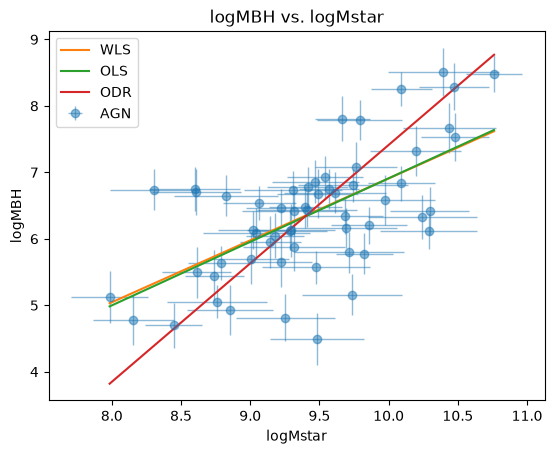

In [5]:
from scipy import odr

y = df["logMBH"].values
x = df["logMstar"].values

sy = df["err_logMBH"].values
sx = df["err_logMstar"].values

def linear_model(beta, x):
    alpha, intercept = beta
    return alpha * (x - 9.5) + intercept

model = odr.Model(linear_model)
data = odr.RealData(x,y,sx=sx,sy=sy)
odr_fit = odr.ODR(data,model,beta0=[1.0, 10.0])
output = odr_fit.run()

alpha_odr, beta_odr = output.beta
sig_alpha_odr, sig_beta_odr = output.sd_beta

print(f"alpha_ODR = {alpha_odr:.3f} +/- {sig_alpha_odr:.3f}")
print(f"beta_ODR  = {beta_odr:.3f} +/- {sig_beta_odr:.3f}")

xx = np.linspace(x.min(), x.max(), 100)
yy = alpha_hat * (xx - 9.5) + beta_hat
yy_wls = beta_w + alpha_w * (xx - 9.5)
yy_odr = alpha_odr * (xx - 9.5) + beta_odr

plt.errorbar(x,y, xerr=df["err_logMstar"], yerr=df["err_logMBH"], fmt="o",alpha=0.5,linewidth=1,label="AGN")
plt.plot(xx, yy_wls, label="WLS")
plt.plot(xx, yy, label="OLS")
plt.plot(xx,yy_odr,label="ODR")

plt.ylabel("logMBH")
plt.xlabel("logMstar")
plt.legend()
plt.title("logMBH vs. logMstar")
plt.show()

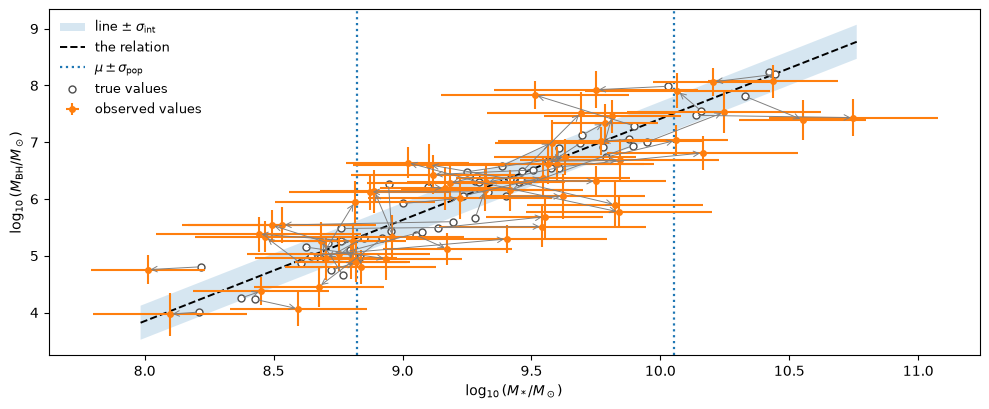

In [6]:
TRUE = {
    "alpha": alpha_odr,
    "beta": beta_odr,
    "sig_int": 0.3,
    "mu": np.mean(x),
    "sig_pop": np.std(x)
}

N_demo = len(df)

rng_m = np.random.default_rng(5)

xt = rng_m.normal(TRUE["mu"], TRUE["sig_pop"], N_demo)
yt = TRUE["alpha"] * (xt - 9.5) + TRUE["beta"] + rng_m.normal(0, TRUE["sig_int"], N_demo)

xo = xt + rng_m.normal(0, sx)
yo = yt + rng_m.normal(0, sy)

fig, ax = plt.subplots(figsize=(10, 4.2))

xx = np.linspace(x.min(), x.max(), 20)
line = TRUE["alpha"] * (xx - 9.5) + TRUE["beta"]

ax.fill_between(
    xx, line - TRUE["sig_int"], line + TRUE["sig_int"],
    alpha=0.18, label=r"line $\pm\ \sigma_{\rm int}$"
)

ax.plot(xx, line, "k", ls="--", lw=1.4, label="the relation")

lo = TRUE["mu"] - TRUE["sig_pop"]
hi = TRUE["mu"] + TRUE["sig_pop"]

ax.axvline(lo, ls=":", lw=1.6)
ax.axvline(hi, ls=":", lw=1.6, label=r"$\mu \pm \sigma_{\rm pop}$")

for a, b, c, d in zip(xt, yt, xo, yo):
    ax.annotate(
        "", xy=(c, d), xytext=(a, b),
        arrowprops=dict(arrowstyle="->", color="0.5", lw=0.7)
    )

ax.plot(xt, yt, "o", mfc="white", mec="0.3", ms=5,
        label="true values")

ax.errorbar(xo, yo, xerr=sx, yerr=sy, fmt="o", ms=4,
            label="observed values")

ax.set_xlabel(r"$\log_{10}(M_*/M_\odot)$")
ax.set_ylabel(r"$\log_{10}(M_{\rm BH}/M_\odot)$")
ax.legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

In [7]:
from scipy.optimize import minimize

def neg_loglike(params):
    alpha, beta, log_sig_int, mu, log_sig_pop = params

    sig_int = np.exp(log_sig_int)
    sig_pop = np.exp(log_sig_pop)

    dx = x - mu
    dy = y - (alpha * (mu - 9.5) + beta)

    Vxx = sig_pop**2 + sx**2
    Vxy = alpha * sig_pop**2
    Vyy = alpha**2 * sig_pop**2 + sig_int**2 + sy**2

    det = Vxx * Vyy - Vxy**2

    chi = (
        Vyy * dx**2
        - 2 * Vxy * dx * dy
        + Vxx * dy**2
    ) / det

    return 0.5 * np.sum(chi + np.log(det) + 2*np.log(2*np.pi))


p0 = [
    alpha_odr,
    beta_odr,
    np.log(0.3),
    np.mean(x),
    np.log(np.std(x))
]

result = minimize(neg_loglike, p0, method="BFGS")

alpha_g, beta_g, log_sig_int_g, mu_g, log_sig_pop_g = result.x

sig_int_g = np.exp(log_sig_int_g)
sig_pop_g = np.exp(log_sig_pop_g)

print(f"mu = {mu_g:.3f}")
print(f"sigma_pop = {sig_pop_g:.3f}")

# Curvature covariance from the BFGS fit
cov_g = np.asarray(result.hess_inv)

sig_alpha_g = np.sqrt(cov_g[0, 0])
sig_beta_g = np.sqrt(cov_g[1, 1])

# sigma_int was fitted in log-space
sig_log_sig_int_g = np.sqrt(cov_g[2, 2])
sig_sig_int_g = sig_int_g * sig_log_sig_int_g

print(f"alpha = {alpha_g:.3f} +/- {sig_alpha_g:.3f}")
print(f"beta = {beta_g:.3f} +/- {sig_beta_g:.3f}")
print(f"sigma_int = {sig_int_g:.3f} +/- {sig_sig_int_g:.3f} dex")

mu = 9.426
sigma_pop = 0.539
alpha = 1.299 +/- 0.210
beta = 6.473 +/- 0.102
sigma_int = 0.519 +/- 0.099 dex


**FINAL ANSWER:** $\alpha = $ 1.299 $\pm$ 0.210 , $\beta = $ 6.473 $\pm$ 0.102 , $\sigma_{\rm int} = $ 0.519 $\pm$ 0.099 dex

**Justification and uncertainty method (a short paragraph):**


For the OLS method, it is the basis for the rest. OLS was the first method, only plotting the line using only the data points. We calculated a simple slope for the points based on that, but it was massively off due to the fact that none of the information of the other error tables was included. Essentially, the goal is to minimize the residual values as much as possible.

For WLS, the emphasis is put on values with more/less error. It weighs each point as 1/y-error^2. A point with less error has much more to contribute to the calculation of the slope than a point with huge errors. This method isn't the most complicated yet, so it still isn't the best.

Now, we start to get somewhere. The ODR model finally accounts for both the x and y-errors, measuring the shortest path, the perpendicular one, to the line. Since our data has both types of errors, utilizing the first two methods is essentially pointless. OLS thinks that the errors don't mean anything, WLS acknowledges y-errors, and ODR takes them both in.

I will report the generative model as the final estimate because it takes into acocunt the full measurements available (including noise) rather than taking x and y at face value. OLS ignores the intrinsic scatter and WLS only incorporates the y-error. ODR does use both, but fails to model intrinsic scatter and population distribution.

## Part 3: The verification plan, written first and then executed (35%)

**Before you run anything below, write the plan** (3a). A verification plan you invent
after seeing the results is a rationalization.

**3a. The plan.** List the checks you will run to decide whether to trust your Part 2
numbers. At minimum, address:

1. **Closure**: simulate a dataset with a truth *you* choose (the generative recipe in
   Part 2 tells you exactly how) and confirm your fit recovers it.
2. **Bias and efficiency**: Monte Carlo all four estimators on many simulated datasets at
   plausible parameters. Plot each estimator's bias and variance for $\alpha$. This is
   *the* figure of this lab.
3. **Coverage**: across your simulations, do your 68% intervals contain the truth 68% of
   the time, for all three reported parameters?
4. **Sensitivity**: what happens to $\hat\alpha$ if the catalog $x$-errors are wrong by
   ±50% (generate correctly, fit with the mis-stated errors)? If the true population isn't Gaussian (try drawing $x^{\rm true}$ from a uniform
   distribution with the same mean and variance instead)? If you had assumed $\sigma_{\rm int} = 0$?

For **each** check, state *in advance* what failure would look like. A check that cannot
fail is not a check.

**3b. The execution.** Run the plan. Report what each check found, including anything that
failed or surprised you. A failed check honestly reported and diagnosed is worth more than
a wall of green checkmarks.

**VERIFICATION PLAN (write this before running 3b):**

I am going to test the four parameters using the simulated data model from above. I will look at a closure test to determine whether the fitting can recover the known inputs. Additionally, I will run a Monte Carlo over simulated datasets and combare the bias and variance of the alpha slope for OLS, WLS, ODR, and generative model. 

For the sensitivity, we can perturb the data and give it incorrect x-measurements We can use non-Gaussian population while keeping mean and variance the same. Checking the values before running it will further confirm that we understand the values that it produces. 

I can run Monte Carlo tests to check bias and efficiency, observing if it leaves the true alpha values. 

I will check for 68% intervals as well within these simulations. 

When plotting the models values on the original data set, failure would be a deviation from the truth value line. Additionally, failure is the inability to reproduce the true values I will be assigning below, of course, getting it spot on might not be entirely possible, but I am expecting one model to recover the truth a lot closer to the expected values than the others. Failure also includes getting a high-value bias and under or overpredicting the true alpha values.

For sensitivity, if the errors were off by 50%. OLS and WLSS don't use X errors, so they're biased likely won't change. However, the ODR and generative model likely will increase bias if the error grows, the fit will think that more of the scatter is noise, so it will overcorrect and be positive if we decrease the error, it will do the opposite and become negative bias. So if you half the error, it's very likely that the data should produce negative bias, but if you increase the error be positive and higher for ODR and generative while staying the same for WLS and OLS. The uniform distribution is similar to what we've done in the model today, so I assume that across all four models, the bias would be nearly identical. If sigma INT is zero, it will not be accounted for in the calculations, and therefore need to be made up for somewhere else, causing the bias to increase among the generative model where it is accounted for.

In [8]:
def simulate_data(alpha, beta, sig_int, mu, sig_pop,
                  sx, sy, rng, uniform_x=False):

    N = len(sx)

    if uniform_x:
        half_width = np.sqrt(3) * sig_pop
        xt = rng.uniform(mu - half_width,
                         mu + half_width, N)
    else:
        xt = rng.normal(mu, sig_pop, N)

    yt = (
        alpha * (xt - 9.5)
        + beta
        + rng.normal(0, sig_int, N)
    )

    xo = xt + rng.normal(0, sx)
    yo = yt + rng.normal(0, sy)

    return xo, yo

In [9]:
TRUE_TEST = { #OUR TRUE VALUES. Just some random garbage, basically.
    "alpha": 0.8,
    "beta": 7.0,
    "sig_int": 0.3,
    "mu": np.mean(x),
    "sig_pop": np.std(x)
}

In [10]:
sx_true = df["err_logMstar"].values
sy_true = df["err_logMBH"].values

In [11]:
rng = np.random.default_rng(12345)

x_test, y_test = simulate_data(
    TRUE_TEST["alpha"],
    TRUE_TEST["beta"],
    TRUE_TEST["sig_int"],
    TRUE_TEST["mu"],
    TRUE_TEST["sig_pop"],
    sx_true,
    sy_true,
    rng
)

Random test has been made. Let's test it on a bunch of methods.

In [12]:
def fit_generative(x_fit, y_fit, sx_fit, sy_fit):

    def neg_loglike(params):
        alpha, beta, log_sig_int, mu, log_sig_pop = params

        sig_int = np.exp(log_sig_int)
        sig_pop = np.exp(log_sig_pop)

        dx = x_fit - mu
        dy = y_fit - (alpha * (mu - 9.5) + beta)

        Vxx = sig_pop**2 + sx_fit**2
        Vxy = alpha * sig_pop**2
        Vyy = alpha**2 * sig_pop**2 + sig_int**2 + sy_fit**2

        det = Vxx * Vyy - Vxy**2

        chi = (
            Vyy * dx**2
            - 2 * Vxy * dx * dy
            + Vxx * dy**2
        ) / det

        return 0.5 * np.sum(
            chi + np.log(det) + 2*np.log(2*np.pi)
        )

    A = np.vstack([np.ones_like(x_fit), x_fit - 9.5]).T

    theta_w, cov_w = wls(A, y_fit, sy_fit)
    beta_start, alpha_start = theta_w

    p0 = [
        alpha_start,
        beta_start,
        np.log(0.3),
        np.mean(x_fit),
        np.log(np.std(x_fit))
    ]

    result = minimize(neg_loglike, p0, method="BFGS")

    alpha, beta, log_sig_int, mu, log_sig_pop = result.x

    sig_int = np.exp(log_sig_int)
    sig_pop = np.exp(log_sig_pop)

    cov = np.asarray(result.hess_inv)
    sig_params = np.sqrt(np.diag(cov))

    sig_alpha = sig_params[0]
    sig_beta = sig_params[1]
    sig_sig_int = sig_int * sig_params[2]

    return {
        "alpha": alpha,
        "beta": beta,
        "sig_int": sig_int,
        "mu": mu,
        "sig_pop": sig_pop,
        "sig_alpha": sig_alpha,
        "sig_beta": sig_beta,
        "sig_sig_int": sig_sig_int,
        "success": result.success
    }


def fit_all(x_sim, y_sim, sx_fit, sy_fit):

    # OLS
    A = np.vstack([np.ones_like(x_sim), x_sim - 9.5]).T
    theta_ols, cov_ols, resid_ols = ols(A, y_sim)

    beta_ols, alpha_ols = theta_ols
    sig_beta_ols, sig_alpha_ols = np.sqrt(np.diag(cov_ols))

    # WLS
    theta_w, cov_w = wls(A, y_sim, sy_fit)

    beta_w, alpha_w = theta_w
    sig_beta_w, sig_alpha_w = np.sqrt(np.diag(cov_w))

    # ODR
    data = odr.RealData(
        x_sim, y_sim,
        sx=sx_fit,
        sy=sy_fit
    )

    model = odr.Model(linear_model)

    fit = odr.ODR(
        data,
        model,
        beta0=[alpha_w, beta_w]
    )

    output = fit.run()

    alpha_odr, beta_odr = output.beta
    sig_alpha_odr, sig_beta_odr = output.sd_beta

    # Generative model
    gen = fit_generative(
        x_sim,
        y_sim,
        sx_fit,
        sy_fit
    )

    return {
        "alpha_ols": alpha_ols,
        "sig_alpha_ols": sig_alpha_ols,

        "alpha_wls": alpha_w,
        "sig_alpha_wls": sig_alpha_w,

        "alpha_odr": alpha_odr,
        "sig_alpha_odr": sig_alpha_odr,

        "alpha_gen": gen["alpha"],
        "sig_alpha_gen": gen["sig_alpha"],

        "beta_gen": gen["beta"],
        "sig_beta_gen": gen["sig_beta"],

        "sigint_gen": gen["sig_int"],
        "sig_sigint_gen": gen["sig_sig_int"],

        "success_gen": gen["success"],

        "beta_ols": beta_ols,
        "beta_wls": beta_w,
        "beta_odr": beta_odr
    }

In [13]:
closure = fit_all(
    x_test,
    y_test,
    sx_true,
    sy_true
)

print("TRUE VALUES")
print(f"alpha     = {TRUE_TEST['alpha']:.3f}")
print(f"beta      = {TRUE_TEST['beta']:.3f}")
print(f"sigma_int = {TRUE_TEST['sig_int']:.3f}")

print("\nRECOVERED VALUES")
print(f"OLS alpha = {closure['alpha_ols']:.3f} +/- {closure['sig_alpha_ols']:.3f}")
print(f"WLS alpha = {closure['alpha_wls']:.3f} +/- {closure['sig_alpha_wls']:.3f}")
print(f"ODR alpha = {closure['alpha_odr']:.3f} +/- {closure['sig_alpha_odr']:.3f}")

print(
    f"GEN alpha = {closure['alpha_gen']:.3f} "
    f"+/- {closure['sig_alpha_gen']:.3f}"
)

print(
    f"GEN beta = {closure['beta_gen']:.3f} "
    f"+/- {closure['sig_beta_gen']:.3f}"
)

print(
    f"GEN sigma_int = {closure['sigint_gen']:.3f} "
    f"+/- {closure['sig_sigint_gen']:.3f}"
)
print(
    f"Beta OLS = {closure['beta_ols']:.3f} \n"
    f"Beta WLS = {closure['beta_wls']:.3f} \n"
    f"Beta ODR = {closure['beta_odr']:.3f} "
)


TRUE VALUES
alpha     = 0.800
beta      = 7.000
sigma_int = 0.300

RECOVERED VALUES
OLS alpha = 0.693 +/- 0.085
WLS alpha = 0.720 +/- 0.059
ODR alpha = 0.891 +/- 0.094
GEN alpha = 0.810 +/- 0.106
GEN beta = 6.999 +/- 0.066
GEN sigma_int = 0.278 +/- 0.074
Beta OLS = 6.984 
Beta WLS = 6.994 
Beta ODR = 7.002 


Can the estimator recover the known truths under the conditions of which the simulations claims the truth is?

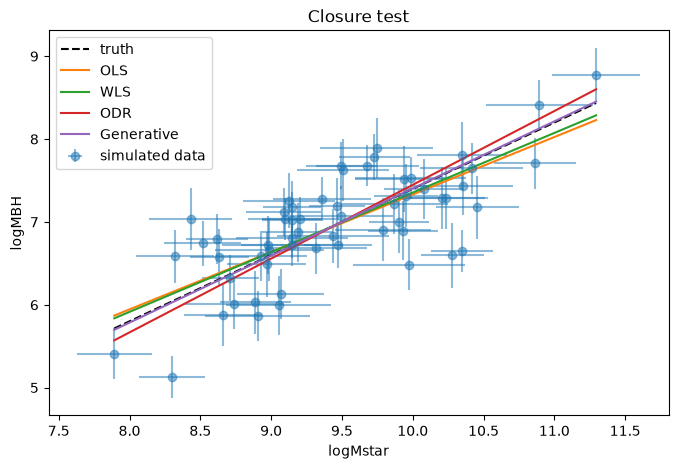

In [14]:
xx = np.linspace(x_test.min(), x_test.max(), 200)

plt.figure(figsize=(8, 5))
plt.errorbar(x_test, y_test, xerr=sx_true, yerr=sy_true,
             fmt="o", alpha=0.5, label="simulated data")
plt.plot(xx, TRUE_TEST["alpha"] * (xx - 9.5) + TRUE_TEST["beta"], "k--", label="truth")

labels = {"ols": "OLS", "wls": "WLS", "odr": "ODR", "gen": "Generative"}
for k, lab in labels.items():
    plt.plot(xx, closure[f"alpha_{k}"] * (xx - 9.5) + closure[f"beta_{k}"], label=lab)

plt.xlabel("logMstar"); plt.ylabel("logMBH")
plt.title("Closure test"); plt.legend(); plt.show()

In [15]:
N_MC = 500

rng_mc = np.random.default_rng(20260929)

alpha_ols_mc = []
alpha_wls_mc = []
alpha_odr_mc = []
alpha_gen_mc = []

sig_alpha_ols_mc = []
sig_alpha_wls_mc = []
sig_alpha_odr_mc = []
sig_alpha_gen_mc = []

beta_gen_mc = []
sig_beta_gen_mc = []

sigint_gen_mc = []
sig_sigint_gen_mc = []

success_mc = []

for i in range(N_MC):

    x_sim, y_sim = simulate_data(
        TRUE_TEST["alpha"],
        TRUE_TEST["beta"],
        TRUE_TEST["sig_int"],
        TRUE_TEST["mu"],
        TRUE_TEST["sig_pop"],
        sx_true,
        sy_true,
        rng_mc
    )

    fit = fit_all(
        x_sim,
        y_sim,
        sx_true,
        sy_true
    )

    alpha_ols_mc.append(fit["alpha_ols"])
    alpha_wls_mc.append(fit["alpha_wls"])
    alpha_odr_mc.append(fit["alpha_odr"])
    alpha_gen_mc.append(fit["alpha_gen"])

    sig_alpha_ols_mc.append(fit["sig_alpha_ols"])
    sig_alpha_wls_mc.append(fit["sig_alpha_wls"])
    sig_alpha_odr_mc.append(fit["sig_alpha_odr"])
    sig_alpha_gen_mc.append(fit["sig_alpha_gen"])

    beta_gen_mc.append(fit["beta_gen"])
    sig_beta_gen_mc.append(fit["sig_beta_gen"])

    sigint_gen_mc.append(fit["sigint_gen"])
    sig_sigint_gen_mc.append(fit["sig_sigint_gen"])

    success_mc.append(fit["success_gen"])


alpha_ols_mc = np.array(alpha_ols_mc)
alpha_wls_mc = np.array(alpha_wls_mc)
alpha_odr_mc = np.array(alpha_odr_mc)
alpha_gen_mc = np.array(alpha_gen_mc)

sig_alpha_ols_mc = np.array(sig_alpha_ols_mc)
sig_alpha_wls_mc = np.array(sig_alpha_wls_mc)
sig_alpha_odr_mc = np.array(sig_alpha_odr_mc)
sig_alpha_gen_mc = np.array(sig_alpha_gen_mc)

beta_gen_mc = np.array(beta_gen_mc)
sig_beta_gen_mc = np.array(sig_beta_gen_mc)

sigint_gen_mc = np.array(sigint_gen_mc)
sig_sigint_gen_mc = np.array(sig_sigint_gen_mc)

In [16]:
methods = ["OLS", "WLS", "ODR", "Generative"]

alpha_results = [
    alpha_ols_mc,
    alpha_wls_mc,
    alpha_odr_mc,
    alpha_gen_mc
]

bias = np.array([
    np.mean(a) - TRUE_TEST["alpha"]
    for a in alpha_results
])

variance = np.array([
    np.var(a, ddof=1)
    for a in alpha_results
])

std = np.sqrt(variance)

for name, b, v, s in zip(methods, bias, variance, std):
    print(
        f"{name:10s} "
        f"bias = {b:+.4f}, "
        f"variance = {v:.4f}, "
        f"std = {s:.4f}"
    )

OLS        bias = -0.1569, variance = 0.0101, std = 0.1003
WLS        bias = -0.1569, variance = 0.0100, std = 0.1001
ODR        bias = +0.1275, variance = 0.0215, std = 0.1465
Generative bias = +0.0132, variance = 0.0173, std = 0.1314


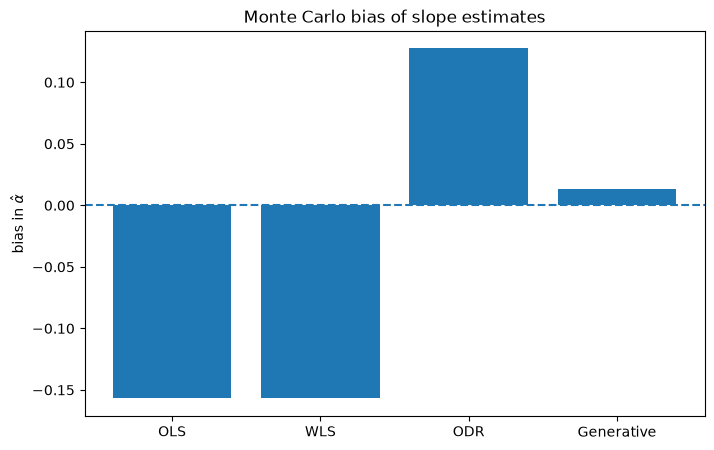

In [17]:
plt.figure(figsize=(8,5))

plt.axhline(0, linestyle="--")

plt.bar(methods, bias)

plt.ylabel(r"bias in $\hat{\alpha}$")
plt.title("Monte Carlo bias of slope estimates")

plt.show()

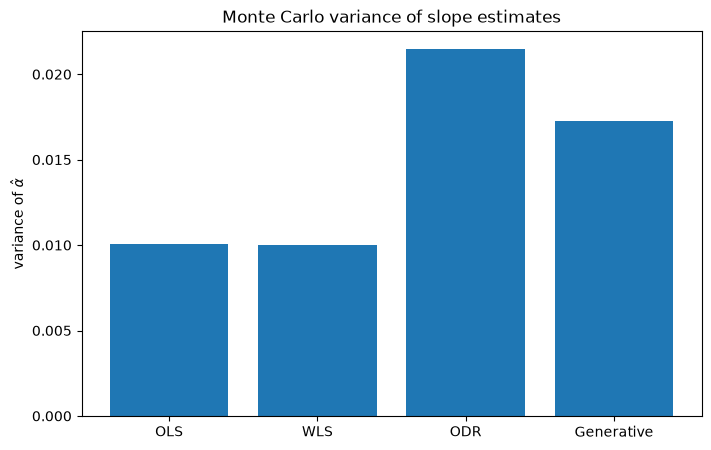

In [18]:
plt.figure(figsize=(8,5))

plt.bar(methods, variance)

plt.ylabel(r"variance of $\hat{\alpha}$")
plt.title("Monte Carlo variance of slope estimates")

plt.show()

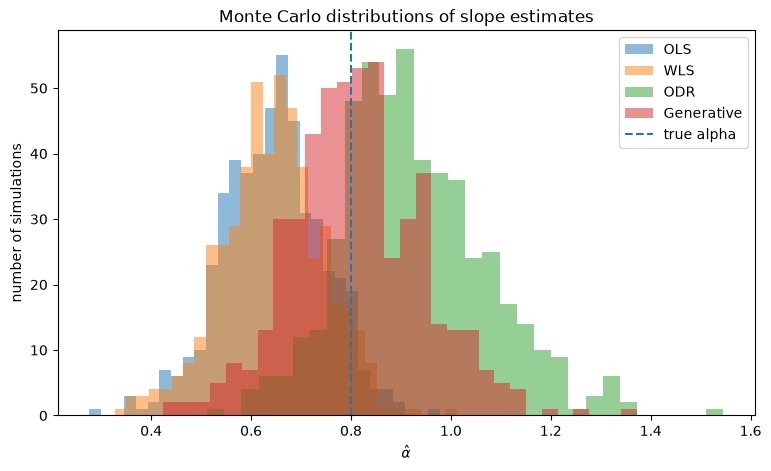

In [19]:
plt.figure(figsize=(9,5))

plt.hist(alpha_ols_mc, bins=30, alpha=0.5, label="OLS")
plt.hist(alpha_wls_mc, bins=30, alpha=0.5, label="WLS")
plt.hist(alpha_odr_mc, bins=30, alpha=0.5, label="ODR")
plt.hist(alpha_gen_mc, bins=30, alpha=0.5, label="Generative")

plt.axvline(
    TRUE_TEST["alpha"],
    linestyle="--",
    label="true alpha"
)

plt.xlabel(r"$\hat{\alpha}$")
plt.ylabel("number of simulations")
plt.title("Monte Carlo distributions of slope estimates")
plt.legend()

plt.show()

In [20]:
coverage_alpha = np.mean(
    np.abs(alpha_gen_mc - TRUE_TEST["alpha"])
    <= sig_alpha_gen_mc
)

coverage_beta = np.mean(
    np.abs(beta_gen_mc - TRUE_TEST["beta"])
    <= sig_beta_gen_mc
)

coverage_sigint = np.mean(
    np.abs(sigint_gen_mc - TRUE_TEST["sig_int"])
    <= sig_sigint_gen_mc
)

print(f"alpha coverage     = {coverage_alpha:.3f}")
print(f"beta coverage      = {coverage_beta:.3f}")
print(f"sigma_int coverage = {coverage_sigint:.3f}")

alpha coverage     = 0.676
beta coverage      = 0.692
sigma_int coverage = 0.684


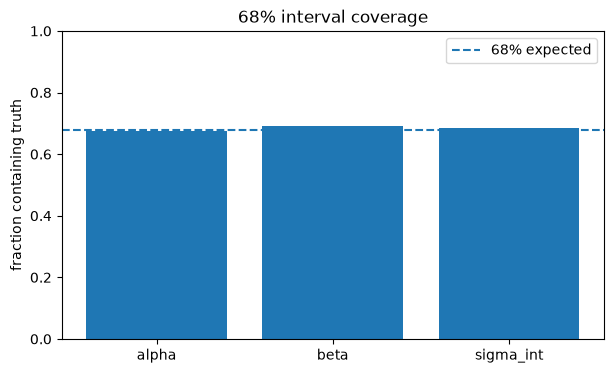

In [21]:
parameters = ["alpha", "beta", "sigma_int"]
coverage = [
    coverage_alpha,
    coverage_beta,
    coverage_sigint
]

plt.figure(figsize=(7,4))

plt.axhline(
    0.68,
    linestyle="--",
    label="68% expected"
)

plt.bar(parameters, coverage)

plt.ylim(0, 1)
plt.ylabel("fraction containing truth")
plt.title("68% interval coverage")
plt.legend()

plt.show()

,Scenario,Method,Bias,SD,RMSE,68% cov
0,baseline,OLS,-0.147,0.106,0.181,0.300
1,baseline,WLS,-0.147,0.108,0.182,0.195
2,baseline,ODR,0.144,0.147,0.206,0.420
3,baseline,Generative,0.030,0.145,0.147,0.620
4,x-errors x0.5 (fit),OLS,-0.147,0.106,0.181,0.300
5,x-errors x0.5 (fit),WLS,-0.147,0.108,0.182,0.195
6,x-errors x0.5 (fit),ODR,-0.059,0.121,0.135,0.490
7,x-errors x0.5 (fit),Generative,-0.107,0.114,0.156,0.425
8,x-errors x1.5 (fit),OLS,-0.147,0.106,0.181,0.300
9,x-errors x1.5 (fit),WLS,-0.147,0.108,0.182,0.195


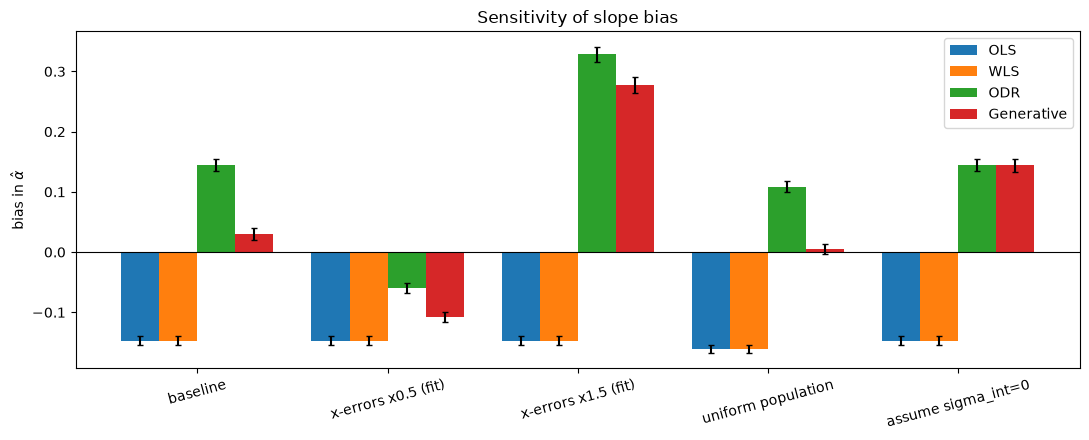

In [22]:
# ================= helpers shared by all three fixes =================
def gen_nll(params, x_fit, y_fit, sx_fit, sy_fit):
    """Negative log-likelihood of the bivariate-Gaussian generative model.
    params = [alpha, beta, log_sig_int, mu, log_sig_pop]"""
    alpha, beta, log_sig_int, mu, log_sig_pop = params
    sig_int, sig_pop = np.exp(log_sig_int), np.exp(log_sig_pop)
    dx = x_fit - mu
    dy = y_fit - (alpha * (mu - 9.5) + beta)
    Vxx = sig_pop**2 + sx_fit**2
    Vxy = alpha * sig_pop**2
    Vyy = alpha**2 * sig_pop**2 + sig_int**2 + sy_fit**2
    det = Vxx * Vyy - Vxy**2
    chi = (Vyy * dx**2 - 2 * Vxy * dx * dy + Vxx * dy**2) / det
    return 0.5 * np.sum(chi + np.log(det) + 2 * np.log(2 * np.pi))


def num_hessian(f, p, rel=1e-4):
    """Central-difference Hessian of f at p."""
    p = np.asarray(p, float)
    n = len(p)
    h = rel * np.maximum(1.0, np.abs(p))
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            pp = p.copy(); pp[i] += h[i]; pp[j] += h[j]; fpp = f(pp)
            pm = p.copy(); pm[i] += h[i]; pm[j] -= h[j]; fpm = f(pm)
            mp = p.copy(); mp[i] -= h[i]; mp[j] += h[j]; fmp = f(mp)
            mm = p.copy(); mm[i] -= h[i]; mm[j] -= h[j]; fmm = f(mm)
            H[i, j] = H[j, i] = (fpp - fpm - fmp + fmm) / (4 * h[i] * h[j])
    return H


def fit_gen_full(x_fit, y_fit, sx_fit, sy_fit):
    """Generative fit that returns the optimizer result too (for Hessian checks)."""
    f = lambda p: gen_nll(p, x_fit, y_fit, sx_fit, sy_fit)
    A = np.vstack([np.ones_like(x_fit), x_fit - 9.5]).T
    (b0, a0), _ = wls(A, y_fit, sy_fit)
    p0 = [a0, b0, np.log(0.3), np.mean(x_fit), np.log(np.std(x_fit))]
    return minimize(f, p0, method="BFGS"), f


def fit_gen_sigint0(x_fit, y_fit, sx_fit, sy_fit):
    """Generative fit with sigma_int forced to 0 (log_sig_int = -inf)."""
    def f4(p):
        alpha, beta, mu, log_sig_pop = p
        return gen_nll([alpha, beta, -np.inf, mu, log_sig_pop],
                       x_fit, y_fit, sx_fit, sy_fit)
    A = np.vstack([np.ones_like(x_fit), x_fit - 9.5]).T
    (b0, a0), _ = wls(A, y_fit, sy_fit)
    res = minimize(f4, [a0, b0, np.mean(x_fit), np.log(np.std(x_fit))], method="BFGS")
    return res.x[0], np.sqrt(res.hess_inv[0, 0])


# ================= 1. SENSITIVITY CHECKS =================
N_SENS = 200
sens = {}   # scenario -> {method: (alpha_hat array, sigma array)}

def run_scenario(name, sx_fit_scale=1.0, uniform_x=False, sigint0=False, seed=777):
    rng_s = np.random.default_rng(seed)     # same seed -> same simulated data in every scenario
    store = {m: ([], []) for m in ["OLS", "WLS", "ODR", "Generative"]}
    for _ in range(N_SENS):
        xs, ys = simulate_data(TRUE_TEST["alpha"], TRUE_TEST["beta"], TRUE_TEST["sig_int"],
                               TRUE_TEST["mu"], TRUE_TEST["sig_pop"],
                               sx_true, sy_true, rng_s, uniform_x=uniform_x)
        sx_fit = sx_true * sx_fit_scale      # generated with sx_true, FIT with the wrong errors
        fit = fit_all(xs, ys, sx_fit, sy_true)
        for m, k in [("OLS", "ols"), ("WLS", "wls"), ("ODR", "odr"), ("Generative", "gen")]:
            store[m][0].append(fit[f"alpha_{k}"]); store[m][1].append(fit[f"sig_alpha_{k}"])
        if sigint0:                          # replace the generative entry with the sigma_int=0 fit
            a, s = fit_gen_sigint0(xs, ys, sx_fit, sy_true)
            store["Generative"][0][-1] = a; store["Generative"][1][-1] = s
    sens[name] = {m: (np.array(a), np.array(s)) for m, (a, s) in store.items()}

run_scenario("baseline")
run_scenario("x-errors x0.5 (fit)", sx_fit_scale=0.5)
run_scenario("x-errors x1.5 (fit)", sx_fit_scale=1.5)
run_scenario("uniform population", uniform_x=True)
run_scenario("assume sigma_int=0", sigint0=True)

rows = []
for scen, d in sens.items():
    for m, (a, s) in d.items():
        rows.append({"Scenario": scen, "Method": m,
                     "Bias": a.mean() - TRUE_TEST["alpha"],
                     "SD": a.std(ddof=1),
                     "RMSE": np.sqrt(np.mean((a - TRUE_TEST["alpha"])**2)),
                     "68% cov": np.mean(np.abs(a - TRUE_TEST["alpha"]) <= s)})
sens_table = pd.DataFrame(rows)
display(sens_table.round(3))

# bias by scenario, with Monte Carlo error bars (SD / sqrt(N))
scen_names = list(sens.keys()); meths = ["OLS", "WLS", "ODR", "Generative"]
fig, ax = plt.subplots(figsize=(11, 4.5)); w = 0.2
for k, m in enumerate(meths):
    b = [sens[s][m][0].mean() - TRUE_TEST["alpha"] for s in scen_names]
    e = [sens[s][m][0].std(ddof=1) / np.sqrt(N_SENS) for s in scen_names]
    ax.bar(np.arange(len(scen_names)) + (k - 1.5) * w, b, w, yerr=e, label=m, capsize=2)
ax.axhline(0, color="k", lw=0.8)
ax.set_xticks(range(len(scen_names))); ax.set_xticklabels(scen_names, rotation=15)
ax.set_ylabel(r"bias in $\hat\alpha$"); ax.set_title("Sensitivity of slope bias"); ax.legend()
plt.tight_layout(); plt.show()

In [23]:
N_H = 100
rng_h = np.random.default_rng(4242)
ratio_a, ratio_b, cov_hi, cov_num = [], [], [], []

for _ in range(N_H):
    xs, ys = simulate_data(TRUE_TEST["alpha"], TRUE_TEST["beta"], TRUE_TEST["sig_int"],
                           TRUE_TEST["mu"], TRUE_TEST["sig_pop"], sx_true, sy_true, rng_h)
    res, f = fit_gen_full(xs, ys, sx_true, sy_true)
    try:
        cov_n = np.linalg.inv(num_hessian(f, res.x))
        sa_n, sb_n = np.sqrt(cov_n[0, 0]), np.sqrt(cov_n[1, 1])
    except Exception:
        continue
    if not (np.isfinite(sa_n) and np.isfinite(sb_n)):
        continue
    sa_h, sb_h = np.sqrt(res.hess_inv[0, 0]), np.sqrt(res.hess_inv[1, 1])
    ratio_a.append(sa_h / sa_n); ratio_b.append(sb_h / sb_n)
    cov_hi.append(abs(res.x[0] - TRUE_TEST["alpha"]) <= sa_h)
    cov_num.append(abs(res.x[0] - TRUE_TEST["alpha"]) <= sa_n)

print(f"datasets compared: {len(ratio_a)}")
print(f"sigma_alpha (hess_inv / numerical): median {np.median(ratio_a):.3f}, "
      f"range {np.min(ratio_a):.2f}-{np.max(ratio_a):.2f}")
print(f"sigma_beta  (hess_inv / numerical): median {np.median(ratio_b):.3f}, "
      f"range {np.min(ratio_b):.2f}-{np.max(ratio_b):.2f}")
print(f"alpha coverage, hess_inv:          {np.mean(cov_hi):.3f}")
print(f"alpha coverage, numerical Hessian: {np.mean(cov_num):.3f}")

datasets compared: 100
sigma_alpha (hess_inv / numerical): median 1.002, range 0.89-1.07
sigma_beta  (hess_inv / numerical): median 1.011, range 0.86-1.08
alpha coverage, hess_inv:          0.780
alpha coverage, numerical Hessian: 0.790


One thing I did not consider that Claude recommended I look into was HESS_INV. Minimizing the negative log likelihood function in my generative data set cell uses BFGS model. and the HESS_INV is built from gradient history, which can be inaccurate. The check above refits 100 simulated data sets and compares sigma alpha and sigma beta to those from my Hessian the median ratio ended up being just around one for both, and the range does not appear to be very drastic.

MONTE CARLO (500 datasets)


,True α,Mean α̂,Bias,SD,RMSE
Method,,,,,
OLS,0.8,0.643,-0.157,0.100,0.186
WLS,0.8,0.643,-0.157,0.100,0.186
ODR,0.8,0.927,0.127,0.146,0.194
Generative,0.8,0.813,0.013,0.131,0.132


CLOSURE TEST (one dataset)


,True,Recovered,σ (reported),Offset,Offset / σ
OLS α,0.8,0.693,0.085,-0.107,-1.251
WLS α,0.8,0.720,0.059,-0.080,-1.356
ODR α,0.8,0.891,0.094,0.091,0.968
Generative α,0.8,0.810,0.106,0.010,0.091
Generative β,7.0,6.999,0.066,-0.001,-0.010
Generative σ_int,0.3,0.278,0.074,-0.022,-0.296


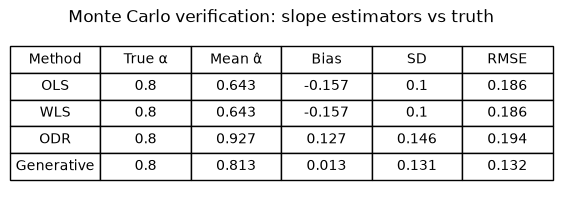

In [24]:
import pandas as pd

# --- Table 1: Monte Carlo slope table (screenshot style) ---
mc = {
    "OLS": alpha_ols_mc,
    "WLS": alpha_wls_mc,
    "ODR": alpha_odr_mc,
    "Generative": alpha_gen_mc,
}

mc_table = pd.DataFrame({
    "True α": [TRUE_TEST["alpha"]] * len(mc),
    "Mean α̂": [a.mean() for a in mc.values()],
    "Bias": [a.mean() - TRUE_TEST["alpha"] for a in mc.values()],
    "SD": [a.std(ddof=1) for a in mc.values()],
    "RMSE": [np.sqrt(np.mean((a - TRUE_TEST["alpha"])**2)) for a in mc.values()],
}, index=list(mc.keys()))
mc_table.index.name = "Method"

# --- Table 2: closure test (single simulated dataset) vs truth ---
closure_table = pd.DataFrame({
    "True": [TRUE_TEST["alpha"]] * 4,
    "Recovered": [closure["alpha_ols"], closure["alpha_wls"],
                  closure["alpha_odr"], closure["alpha_gen"]],
    "σ (reported)": [closure["sig_alpha_ols"], closure["sig_alpha_wls"],
                     closure["sig_alpha_odr"], closure["sig_alpha_gen"]],
}, index=["OLS α", "WLS α", "ODR α", "Generative α"])
closure_table["Offset"] = closure_table["Recovered"] - closure_table["True"]
closure_table["Offset / σ"] = closure_table["Offset"] / closure_table["σ (reported)"]

# generative-only rows for beta and sigma_int
extra = pd.DataFrame({
    "True": [TRUE_TEST["beta"], TRUE_TEST["sig_int"]],
    "Recovered": [closure["beta_gen"], closure["sigint_gen"]],
    "σ (reported)": [closure["sig_beta_gen"], closure["sig_sigint_gen"]],
}, index=["Generative β", "Generative σ_int"])
extra["Offset"] = extra["Recovered"] - extra["True"]
extra["Offset / σ"] = extra["Offset"] / extra["σ (reported)"]

closure_table = pd.concat([closure_table, extra])

print("MONTE CARLO (500 datasets)")
display(mc_table.round(3))

print("CLOSURE TEST (one dataset)")
display(closure_table.round(3))

# --- Optional: render Table 1 as a figure you can drop into the report ---
fig, ax = plt.subplots(figsize=(7, 2))
ax.axis("off")
tbl = ax.table(
    cellText=mc_table.round(3).reset_index().values,
    colLabels=["Method"] + list(mc_table.columns),
    loc="center", cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.6)
plt.title("Monte Carlo verification: slope estimators vs truth", pad=10)
plt.show()

**WHAT THE CHECKS FOUND:**

Starting off with the Monte Carlo 500 data sets table above, we can see that OLS and WLS under predicted the true alpha while ORD overpredicted true alpha, the generative model was very close to the true alpha, meaning that it's ratio of error was lower. Additionally, doing our closure test on the simulated data OLSWLS and ORD did not predict alpha as well as the generative model did, under and over predicting. With the Monte Carlo verification, similar results were also produced. Overall, degenerative model was better at recovering the true values because the other models were plagued by their errors, whereas the generative model was able to account for those errors in its calculation. The generative model is nearly unbiased in the Monte Carlo, making it a strong conclusion for using its estimate. Additionally, in the 68% interval table, all three models were extremely close to .68, so the uncertainties quoted are reasonable. The Monte Carlo slope variation shows that OLS and WLS had low variance, but higher bias, while ODR had high bias and high variance in the generative model had very low bias and low variance, usually being correct.

## Part 4: AI-use appendix (10%)

**AI use**: which tools did you use (Copilot, Claude, ChatGPT, none, ...), for what,
what did they get wrong, and how did you catch it? Honesty is graded; "I didn't use any"
is fine if true.

**AI-USE APPENDIX:**

I used ChatGPT when I got to the generative model section and applied a generative model. It made up. I prompted ChatGPT with several questions about the assignments prompt to verify that it was accurately applying the work additionally. I supplied it with lecture code that encouraged it to make similar looking code. I spent most of my time on the verification plan going back-and-forth with ChatGPT to ensure that the code that it was writing for the verification was not here to validate, rather than to simply generate data sets and apply the already written models to that data. I wanted this verification plan to be structured in a way, and all of this was explained to ChatGPT as well, where I would give the truth before calculating any results and then have a comparison at the very end with all of the values calculated by the verification plan compared to the true results. The question was not how well did the model perform, the question was given starter input in these models, can the model recover the initial data? I was able to use visual cues as well as Claude in some cases to double check that the model was not trying to validate itself. I utilized tactics from September 29 lab to prompt ChatGPT to return code that was structured to present information given values rather than to calculate and alter data to get a desired response. 

I even asked ChatGPT to continue creating models to display the predictive habits of my models as you can see in the 68% interval coverage, Monte Carlo distribution of slope elements, and the Monte Carlo slope variance estimates. Additionally, looking at the sensitivity plot, my prediction before in the write-up corresponds with what is observed in the sensitivity plot.